In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(font_scale=1, style='ticks', palette = 'colorblind')

In [8]:
# Read in all distribution CSVs, tagging each with method and energy function
dfs = []
for method in ["relax", "design"]:
    for ef in ["beta_nov16_cart", "beta_jan25_cart"]:
        path = f"../results/{method}_distributions/{ef}/distrs_new_atom_typing.csv"
        df = pd.read_csv(path)
        df["method"] = method
        df["energy_function"] = ef
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data.head()

,distance,ref,input,a1,a2,atoms,method,energy_function
0,1.50,0.0,1.868501e-144,CObb,CHR1,CObb:CHR1,relax,beta_nov16_cart
1,1.55,0.0,8.726339e-137,CObb,CHR1,CObb:CHR1,relax,beta_nov16_cart
2,1.60,0.0,2.495822e-129,CObb,CHR1,CObb:CHR1,relax,beta_nov16_cart
3,1.65,0.0,4.371573e-122,CObb,CHR1,CObb:CHR1,relax,beta_nov16_cart
4,1.70,0.0,4.689262e-115,CObb,CHR1,CObb:CHR1,relax,beta_nov16_cart


In [9]:
# Read KL divergence scores from log files
kl_data = {}
for method in ["relax", "design"]:
    for ef in ["beta_nov16_cart", "beta_jan25_cart"]:
        log_path = f"../logs/compute_{method}_distributions_{ef}.log"
        kl = {}
        with open(log_path) as f:
            lines = f.readlines()
            for line in lines[2:]:  # skip summary line and header
                parts = line.strip().split()
                if len(parts) == 4:
                    a1, a2, kldiv, weight = parts
                    kl[(a1, a2)] = float(kldiv)
        kl_data[(method, ef)] = kl

# Check one entry
list(kl_data[("relax", "beta_nov16_cart")].items())[:3]

[(('CObb', 'CHR1'), 0.017869174423685134),
 (('OCbb', 'CHR1'), 0.010346344766440353),
 (('Nbb', 'CHR1'), 0.016475936621748878)]

In [10]:
atom_f = '../data/new_atom_typing/atom_properties.txt'
with open(atom_f) as f:
    lines = f.readlines()
radius_dict = {}
for line in lines:
    elements = line.split()
    if len(elements) < 4:
        continue
    (name, atom, r, e) = elements[:4]
    try:
        r = float(r)
    except ValueError:
        continue
    radius_dict[name] = r

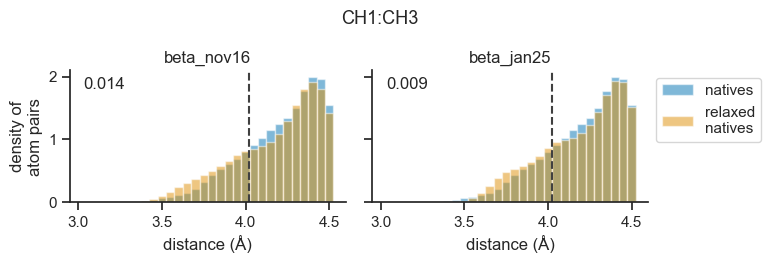

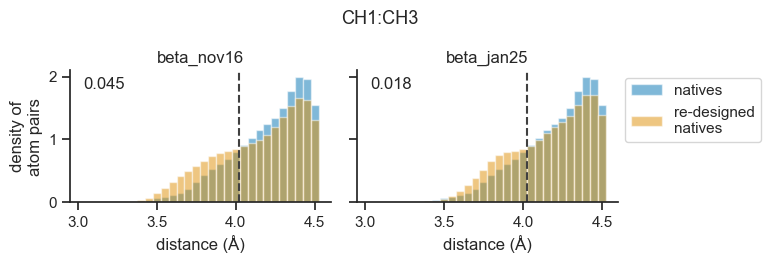

In [35]:
# Get data for a given atom-type pair
a1 = "CH1"
a2 = "CH3"
atom_pair_list = sorted([a1, a2])
sigma = radius_dict[a1] + radius_dict[a2]
min_d = sigma - 1.0
max_d = sigma + 0.5
subset = data[
    (data["distance"].between(min_d, max_d)) &
    (data["a1"] == a1) &
    (data["a2"] == a2)
]

# Plot data
labels = {
    'relax' : 'relaxed\nnatives',
    'design' : 're-designed\nnatives'
}
efs = ['beta_nov16_cart', 'beta_jan25_cart']
for method in ['relax', 'design']:

    fig, axes = plt.subplots(1, 2, figsize=(8, 2.75), sharey=True, sharex=True)

    for ax, ef in zip(axes, efs):
        cond = subset[(subset["method"] == method) & (subset["energy_function"] == ef)]
        ax.bar(cond["distance"], cond["ref"], width=0.05, label="natives", alpha=0.5)
        ax.bar(cond["distance"], cond["input"], width=0.05, label=labels[method], alpha=0.5, linewidth=1)
        ax.axvline(sigma, color="0.25", linestyle="--")
        kl = kl_data[(method, ef)].get((a1, a2), None)
        kl_str = f"{kl:.3f}"
        ax.text(0.05, 0.95, kl_str, transform=ax.transAxes, ha="left", va="top", fontsize=12)
        ax.set_title(f"{ef.replace('_cart', '')}")
        ax.set_xlabel("distance (\u00c5)")

    axes[0].set_ylabel("density of\natom pairs")
    axes[1].legend(bbox_to_anchor=(1,1))
    fig.suptitle(f"{atom_pair_list[0]}:{atom_pair_list[1]}", fontsize=13, y=0.95)
    fig.tight_layout()
    sns.despine()
    plt.show()